In [19]:
!pip install -U tensorflow tensorflow-datasets matplotlib seaborn

# Importing libraries

In [20]:

import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load Malaria Dataset (TFDS)

In [21]:

(ds_train, ds_val, ds_test), ds_info = tfds.load(
    'malaria',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    as_supervised=True,
    with_info=True
)

# Dataset Info

In [22]:

print(ds_info)
class_names = ds_info.features['label'].names
print(class_names)  # ['parasitized', 'uninfected']

tfds.core.DatasetInfo(
    name='malaria',
    full_name='malaria/1.0.0',
    description="""
    The Malaria dataset contains a total of 27,558 cell images with equal instances
    of parasitized and uninfected cells from the thin blood smear slide images of
    segmented cells.
    """,
    homepage='https://lhncbc.nlm.nih.gov/publication/pub9932',
    data_dir='/root/tensorflow_datasets/malaria/1.0.0',
    file_format=tfrecord,
    download_size=337.08 MiB,
    dataset_size=317.62 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=27558, num_shards=4>,
    },
    citation="""@article{rajaraman2018pre,
      title={Pre-trained convolutional neural networks as feature extractors toward
      improved malaria parasit

# Data Visualization

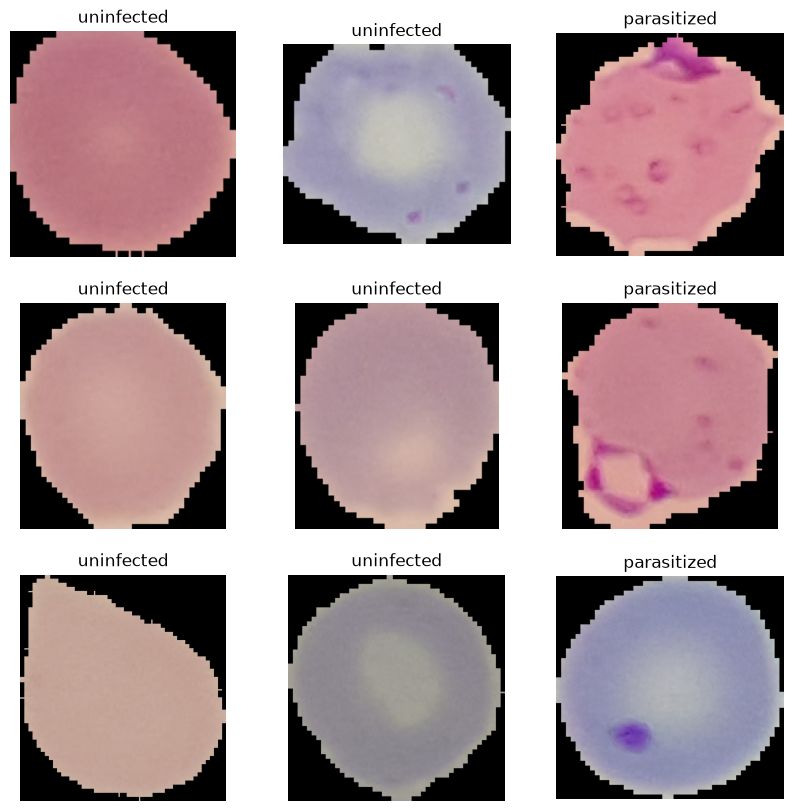

In [23]:

plt.figure(figsize=(10,10))

for i, (img, label) in enumerate(ds_train.take(9)):
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(class_names[label.numpy()])
    plt.axis("off")

plt.show()

# Preprocessing

In [24]:

IMG_SIZE = 224

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image, label

In [25]:

BATCH_SIZE = 32

ds_train = ds_train.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_val = ds_val.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_test = ds_test.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Build Transfer Learning Model (EfficientNetB0)

In [26]:

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

base_model.trainable = False  # freeze base model

# Full Model

In [27]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile Model

In [28]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model

In [29]:

history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=10
)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 88s 89ms/step - accuracy: 0.9022 - loss: 0.2504 - val_accuracy: 0.9390 - val_loss: 0.1704
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 42s 59ms/step - accuracy: 0.9384 - loss: 0.1732 - val_accuracy: 0.9496 - val_loss: 0.1458
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.9439 - loss: 0.1584 - val_accuracy: 0.9514 - val_loss: 0.1369
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.9456 - loss: 0.1484 - val_accuracy: 0.9536 - val_loss: 0.1298
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.9508 - loss: 0.1415 - val_accuracy: 0.9565 - val_loss: 0.1275
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.9512 - loss: 0.1364 - val_accuracy: 0.9568 - val_loss: 0.1236
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.9535 - loss: 0.1330 - val_accuracy: 0.9550 - val_loss: 0.1213
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step - accuracy: 0.9521 - loss: 0.1315 - 

# Evaluate Model

In [30]:
test_loss, test_acc = model.evaluate(ds_test)
print("Test Accuracy:", test_acc)

87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9539 - loss: 0.1282
Test Accuracy: 0.9539186954498291


# Plot Training Results

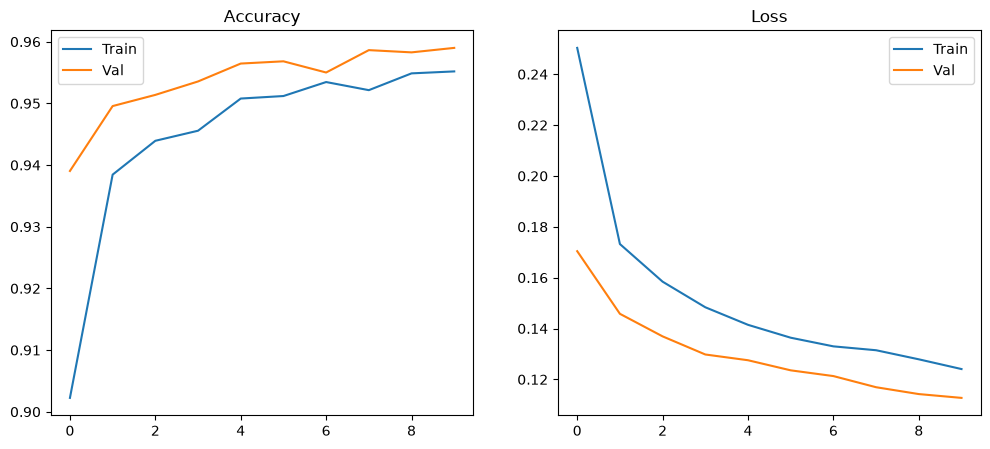

In [31]:

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss")
plt.legend()

plt.show()

# Confusion Matrix (Important for Medical AI)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━

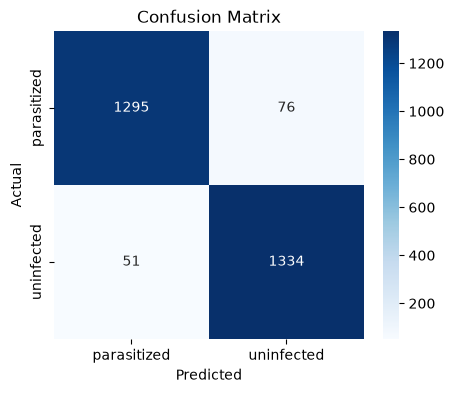

In [32]:

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in ds_test:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report

In [33]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

 parasitized       0.96      0.94      0.95      1371
  uninfected       0.95      0.96      0.95      1385

    accuracy                           0.95      2756
   macro avg       0.95      0.95      0.95      2756
weighted avg       0.95      0.95      0.95      2756



# Save Model

In [34]:
model.save("malaria_efficientnet.h5")